# TP Régression linéaire — Exercice 1 : régression linéaire univariée
Âge (`ex1x.dat`) → taille en mètres (`ex1y.dat`) de 50 enfants.

## 1. Lecture des données

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.loadtxt('ex1x.dat')
y = np.loadtxt('ex1y.dat')
m = len(x)
print(x.shape, y.shape)

(50,) (50,)


## 2. Nuage de points

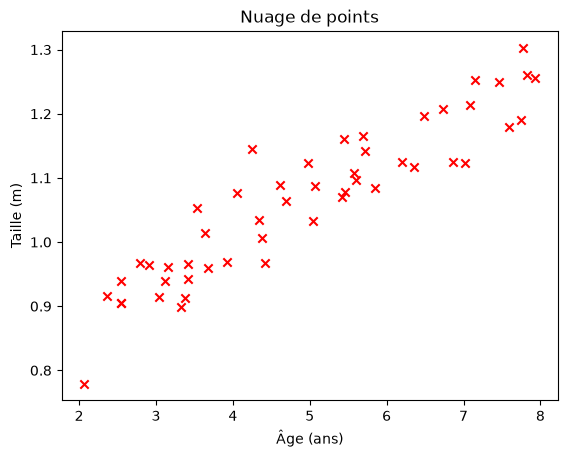

In [2]:
plt.scatter(x, y, c='r', marker='x')
plt.xlabel('Âge (ans)'); plt.ylabel('Taille (m)')
plt.title('Nuage de points')
plt.show()

## 3. Fonction hypothèse
$h_\theta(x)=\theta_0+\theta_1 x$

In [3]:
def h(theta0, theta1, x):
    return theta0 + theta1 * x

## 4. Fonction de coût
$J(\theta)=\frac{1}{2m}\sum_{i=1}^m (h_\theta(x_i)-y_i)^2$

In [4]:
def J(theta0, theta1):
    return np.sum((h(theta0, theta1, x) - y) ** 2) / (2 * m)

## 5. Une itération de descente de gradient
$\theta_0^*=\theta_0-\frac{\alpha}{m}\sum (h_\theta(x_i)-y_i)$, $\theta_1^*=\theta_1-\frac{\alpha}{m}\sum (h_\theta(x_i)-y_i)x_i$ (mise à jour simultanée).

In [5]:
alpha = 0.07

def iteration(theta0, theta1):
    e = h(theta0, theta1, x) - y
    return theta0 - alpha / m * np.sum(e), theta1 - alpha / m * np.sum(e * x)

## 6. Quelques itérations

0.09040986952034924 0.35100518836612754 0.40573668261709966


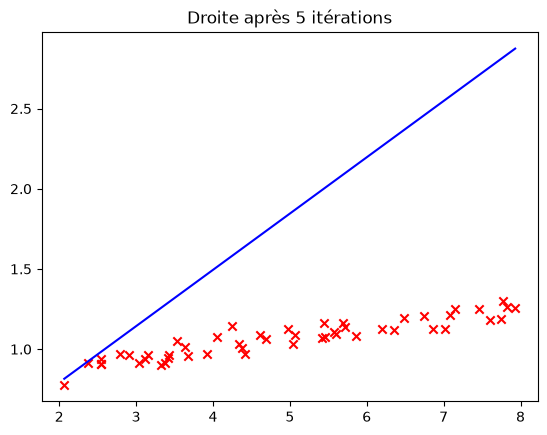

In [6]:
theta0, theta1 = 0.0, 0.0
for k in range(5):
    theta0, theta1 = iteration(theta0, theta1)
print(theta0, theta1, J(theta0, theta1))

plt.scatter(x, y, c='r', marker='x')
xs = np.linspace(x.min(), x.max(), 100)
plt.plot(xs, h(theta0, theta1, xs), 'b')
plt.title('Droite après 5 itérations'); plt.show()

## 7. Convergence
Critère d'arrêt : $\left|\frac{J(\theta^*)-J(\theta)}{J(\theta)}\right|<\varepsilon=10^{-10}$.

itérations : 1512
theta0 = 0.7501514133540008  theta1 = 0.06388318963509147  J = 0.0009870699799372452


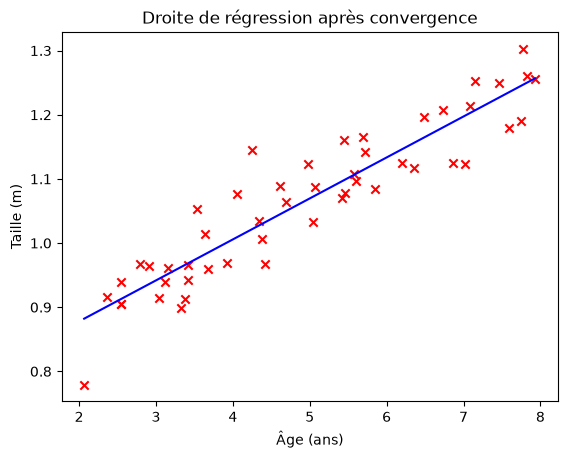

In [7]:
EPS = 1e-10  # seuil du critère d'arrêt
theta0, theta1 = 0.0, 0.0
n_iter = 0
while True:
    j_old = J(theta0, theta1)
    theta0, theta1 = iteration(theta0, theta1)
    j_new = J(theta0, theta1)
    n_iter += 1
    if abs((j_new - j_old) / j_old) < EPS:
        break
print('itérations :', n_iter)
print('theta0 =', theta0, ' theta1 =', theta1, ' J =', j_new)

plt.scatter(x, y, c='r', marker='x')
plt.plot(xs, h(theta0, theta1, xs), 'b')
plt.xlabel('Âge (ans)'); plt.ylabel('Taille (m)')
plt.title('Droite de régression après convergence'); plt.show()

## 8. Prédictions

In [8]:
for age in (3, 5, 7):
    print(f'Âge {age} ans -> taille prédite : {h(theta0, theta1, age):.3f} m')

Âge 3 ans -> taille prédite : 0.942 m
Âge 5 ans -> taille prédite : 1.070 m
Âge 7 ans -> taille prédite : 1.197 m


## 9. Fonction de coût en 3D

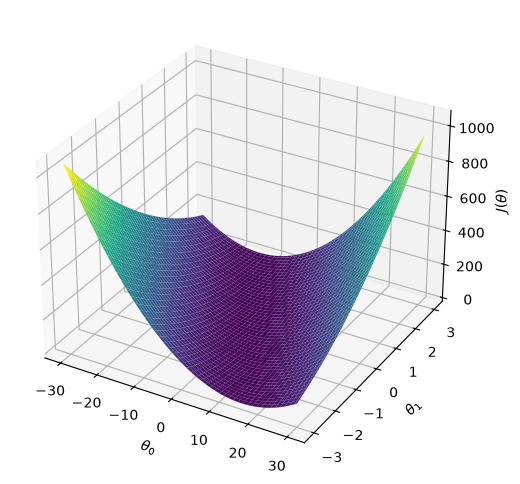

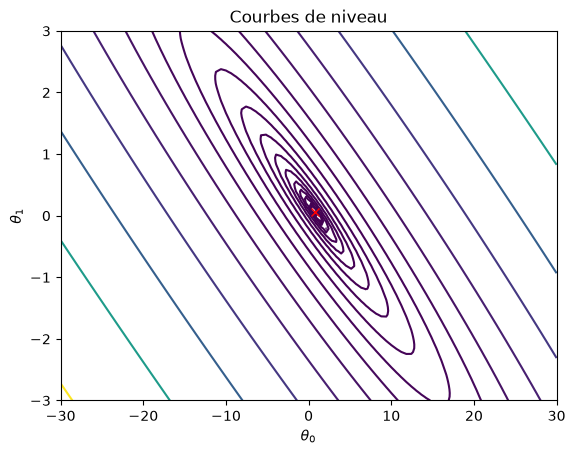

In [9]:
from mpl_toolkits.mplot3d import Axes3D

t0 = np.linspace(-30, 30, 100)
t1 = np.linspace(-3, 3, 100)
T0, T1 = np.meshgrid(t0, t1)
J_vals = np.array([[J(a, b) for a in t0] for b in t1])

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(T0, T1, J_vals, cmap='viridis')
ax.set_xlabel(r'$\theta_0$'); ax.set_ylabel(r'$\theta_1$'); ax.set_zlabel(r'$J(\theta)$')
plt.show()

plt.contour(T0, T1, J_vals, levels=np.logspace(-2, 3, 20))
plt.plot(theta0, theta1, 'rx')
plt.xlabel(r'$\theta_0$'); plt.ylabel(r'$\theta_1$'); plt.title('Courbes de niveau'); plt.show()